In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p

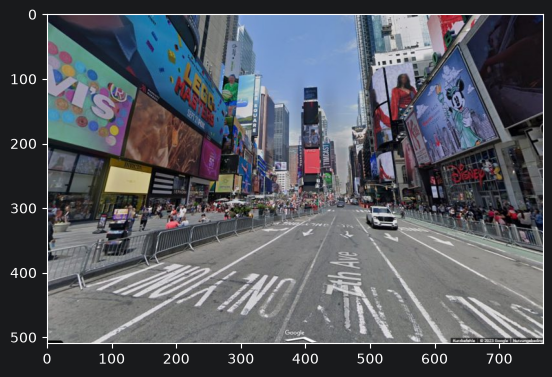

In [2]:
img_path = p.IMAGE_ASSETS / "street.jpg"
img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
plt.figure()
plt.imshow(img)

In [3]:
h, w, _ = img.shape

noisy_img = img.copy()
noise = np.random.rand(h, w)

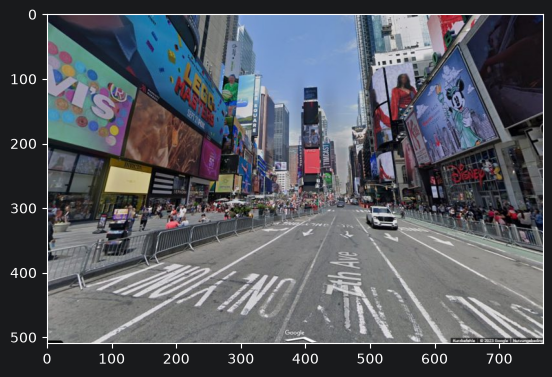

In [4]:
plt.figure()
plt.imshow(noisy_img)

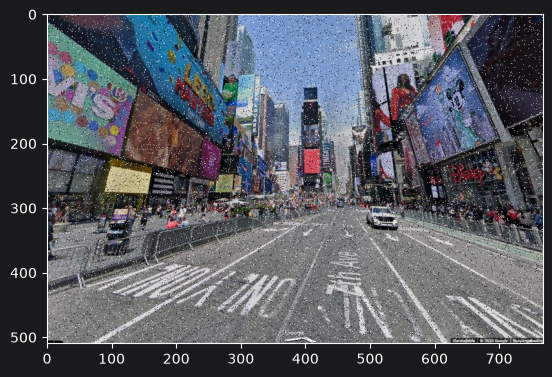

In [5]:
noise_prob = 0.05
noisy_img[noise < noise_prob / 2] = 0
noisy_img[noise > 1 - noise_prob / 2] = 255

plt.figure()
plt.imshow(noisy_img)

In [6]:
def median_filter_callback(value):
    pass

In [7]:
window_name = "median_filtering"
cv2.namedWindow(window_name)

cv2.createTrackbar("k_size", window_name, 1, 100, median_filter_callback)

In [8]:
while True:
    if cv2.waitKey(1) == ord("q"):
        break

    k_size = cv2.getTrackbarPos("k_size", window_name)
    k_size = max(1, k_size)

    if k_size % 2 == 0:
        k_size += 1
        cv2.setTrackbarPos("k_size", window_name, k_size)

    img_filtered = cv2.medianBlur(noisy_img, k_size)

    cv2.imshow(window_name, img_filtered)

cv2.destroyAllWindows()